# 🏥 Patient Readmission & Hospital Performance Analytics

# 🧰 Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats
import pylab

import warnings
warnings.filterwarnings("ignore")

In [2]:
sns.set(style="darkgrid")

This section imports all required libraries for analysis.These libraries help in data handling, visualization and statistics.

# 📥 Load Dataset

In [3]:
df = pd.read_csv(r"C:\Users\Suhani Patra\Downloads\healthcare_project_5000.csv")

In [4]:
df.head()

,PatientID,Age,Gender,Department,Disease,Doctor,AdmissionDate,DischargeDate,LengthOfStay,TreatmentCost
0,P100000,21,Female,Neurology,Stroke,Dr. Neu_3,2025-05-10,2025-05-21,11,49732
1,P100001,75,Other,General Medicine,Infection,Dr. Gen_1,2023-05-02,2023-05-05,3,42194
2,P100002,24,Female,Neurology,Stroke,Dr. Neu_3,2023-03-29,2023-04-03,5,49131
3,P100003,88,Male,Cardiology,Heart Attack,Dr. Car_1,2023-05-11,2023-05-17,6,5769
4,P100004,60,Male,General Medicine,Fever,Dr. Gen_3,2025-03-16,2025-03-18,2,10311


Here we load the dataset into pandas dataframe.This helps in performing analysis easily.

# 🔍 Data Understanding

In [5]:
df.head()

,PatientID,Age,Gender,Department,Disease,Doctor,AdmissionDate,DischargeDate,LengthOfStay,TreatmentCost
0,P100000,21,Female,Neurology,Stroke,Dr. Neu_3,2025-05-10,2025-05-21,11,49732
1,P100001,75,Other,General Medicine,Infection,Dr. Gen_1,2023-05-02,2023-05-05,3,42194
2,P100002,24,Female,Neurology,Stroke,Dr. Neu_3,2023-03-29,2023-04-03,5,49131
3,P100003,88,Male,Cardiology,Heart Attack,Dr. Car_1,2023-05-11,2023-05-17,6,5769
4,P100004,60,Male,General Medicine,Fever,Dr. Gen_3,2025-03-16,2025-03-18,2,10311


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   PatientID      5000 non-null   object
 1   Age            5000 non-null   int64 
 2   Gender         5000 non-null   object
 3   Department     5000 non-null   object
 4   Disease        5000 non-null   object
 5   Doctor         5000 non-null   object
 6   AdmissionDate  5000 non-null   object
 7   DischargeDate  5000 non-null   object
 8   LengthOfStay   5000 non-null   int64 
 9   TreatmentCost  5000 non-null   int64 
dtypes: int64(3), object(7)
memory usage: 390.8+ KB


In [7]:
df.shape

(5000, 10)

In [8]:
df.describe()

,Age,LengthOfStay,TreatmentCost
count,5000.000000,5000.000000,5000.00000
mean,45.143000,7.477400,27281.28800
std,25.618357,4.033949,12848.97541
min,1.000000,1.000000,5009.00000
25%,23.000000,4.000000,16147.25000
50%,46.000000,7.000000,27168.50000
75%,67.000000,11.000000,38556.25000
max,89.000000,14.000000,49974.00000


In [9]:
df.columns

Index(['PatientID', 'Age', 'Gender', 'Department', 'Disease', 'Doctor',
       'AdmissionDate', 'DischargeDate', 'LengthOfStay', 'TreatmentCost'],
      dtype='object')

This step helps in understanding the healthcare dataset structure, column details, patient records, and data types before analysis.

# 🧹 Data Cleaning & Preprocessing

Data cleaning improves data quality.
It includes handling missing values, duplicates, types and outliers.

# 🔍 Missing Value Handling

In [10]:
df.isnull().sum()

PatientID        0
Age              0
Gender           0
Department       0
Disease          0
Doctor           0
AdmissionDate    0
DischargeDate    0
LengthOfStay     0
TreatmentCost    0
dtype: int64

In [12]:
df.head()

,PatientID,Age,Gender,Department,Disease,Doctor,AdmissionDate,DischargeDate,LengthOfStay,TreatmentCost
0,P100000,21,Female,Neurology,Stroke,Dr. Neu_3,2025-05-10,2025-05-21,11,49732
1,P100001,75,Other,General Medicine,Infection,Dr. Gen_1,2023-05-02,2023-05-05,3,42194
2,P100002,24,Female,Neurology,Stroke,Dr. Neu_3,2023-03-29,2023-04-03,5,49131
3,P100003,88,Male,Cardiology,Heart Attack,Dr. Car_1,2023-05-11,2023-05-17,6,5769
4,P100004,60,Male,General Medicine,Fever,Dr. Gen_3,2025-03-16,2025-03-18,2,10311


This step checks for missing or null values in the dataset.Handling missing data is important to ensure accurate analysis and avoid biased results.In this dataset, no missing values were found, indicating clean and complete data.This improves reliability for further analysis and visualization.

# 🔁 CHECK DUPLICATES

In [13]:
df.duplicated().sum()

np.int64(0)

Duplicate records are identified to ensure data uniqueness.Duplicates can lead to incorrect analysis and misleading insights.In this dataset, no duplicate rows were found.This confirms that each record represents unique student data.

# 🔁 Remove DUPLICATES

In [14]:
df = df.drop_duplicates()

In [16]:
df.head()

,PatientID,Age,Gender,Department,Disease,Doctor,AdmissionDate,DischargeDate,LengthOfStay,TreatmentCost
0,P100000,21,Female,Neurology,Stroke,Dr. Neu_3,2025-05-10,2025-05-21,11,49732
1,P100001,75,Other,General Medicine,Infection,Dr. Gen_1,2023-05-02,2023-05-05,3,42194
2,P100002,24,Female,Neurology,Stroke,Dr. Neu_3,2023-03-29,2023-04-03,5,49131
3,P100003,88,Male,Cardiology,Heart Attack,Dr. Car_1,2023-05-11,2023-05-17,6,5769
4,P100004,60,Male,General Medicine,Fever,Dr. Gen_3,2025-03-16,2025-03-18,2,10311


In [17]:
df.duplicated().sum()

np.int64(0)

Any duplicate entries are removed to maintain data integrity.Removing duplicates helps in avoiding repeated information during analysis.Since no duplicates were present, the dataset remains unchanged.This ensures consistent and reliable results.

# 🔤 Data Type Conversion

In [18]:
df.dtypes

PatientID        object
Age               int64
Gender           object
Department       object
Disease          object
Doctor           object
AdmissionDate    object
DischargeDate    object
LengthOfStay      int64
TreatmentCost     int64
dtype: object

In [19]:
df['AdmissionDate'] = pd.to_datetime(df['AdmissionDate'])
df['DischargeDate'] = pd.to_datetime(df['DischargeDate'])

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   PatientID      5000 non-null   object        
 1   Age            5000 non-null   int64         
 2   Gender         5000 non-null   object        
 3   Department     5000 non-null   object        
 4   Disease        5000 non-null   object        
 5   Doctor         5000 non-null   object        
 6   AdmissionDate  5000 non-null   datetime64[ns]
 7   DischargeDate  5000 non-null   datetime64[ns]
 8   LengthOfStay   5000 non-null   int64         
 9   TreatmentCost  5000 non-null   int64         
dtypes: datetime64[ns](2), int64(3), object(5)
memory usage: 390.8+ KB


In [21]:
df['AdmissionDate'].dtype

dtype('<M8[ns]')

In [23]:
df['Gender'] = df['Gender'].astype('category')
df['Department'] = df['Department'].astype('category')
df['Disease'] = df['Disease'].astype('category')
df['Doctor'] = df['Doctor'].astype('category')

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   PatientID      5000 non-null   object        
 1   Age            5000 non-null   int64         
 2   Gender         5000 non-null   category      
 3   Department     5000 non-null   category      
 4   Disease        5000 non-null   category      
 5   Doctor         5000 non-null   category      
 6   AdmissionDate  5000 non-null   datetime64[ns]
 7   DischargeDate  5000 non-null   datetime64[ns]
 8   LengthOfStay   5000 non-null   int64         
 9   TreatmentCost  5000 non-null   int64         
dtypes: category(4), datetime64[ns](2), int64(3), object(1)
memory usage: 257.1+ KB


In [25]:
df['Gender'].dtype

CategoricalDtype(categories=['Female', 'Male', 'Other'], ordered=False, categories_dtype=object)

In [28]:
df.head()

,PatientID,Age,Gender,Department,Disease,Doctor,AdmissionDate,DischargeDate,LengthOfStay,TreatmentCost
0,P100000,21,Female,Neurology,Stroke,Dr. Neu_3,2025-05-10,2025-05-21,11,49732
1,P100001,75,Other,General Medicine,Infection,Dr. Gen_1,2023-05-02,2023-05-05,3,42194
2,P100002,24,Female,Neurology,Stroke,Dr. Neu_3,2023-03-29,2023-04-03,5,49131
3,P100003,88,Male,Cardiology,Heart Attack,Dr. Car_1,2023-05-11,2023-05-17,6,5769
4,P100004,60,Male,General Medicine,Fever,Dr. Gen_3,2025-03-16,2025-03-18,2,10311


Data types are checked and converted into appropriate formats.Correct data types improve analysis accuracy and visualization quality.Categorical and numerical columns are properly structured. This step prepares the dataset for efficient processing.

# ⚙️ Feature Engineering

In [11]:
df['Readmitted'] = np.where(
    (df['LengthOfStay'] > 10) |
    (df['TreatmentCost'] > 30000),
    'Yes',
    'No'
)

In [30]:
df.head()

,PatientID,Age,Gender,Department,Disease,Doctor,AdmissionDate,DischargeDate,LengthOfStay,TreatmentCost,Readmitted
0,P100000,21,Female,Neurology,Stroke,Dr. Neu_3,2025-05-10,2025-05-21,11,49732,Yes
1,P100001,75,Other,General Medicine,Infection,Dr. Gen_1,2023-05-02,2023-05-05,3,42194,Yes
2,P100002,24,Female,Neurology,Stroke,Dr. Neu_3,2023-03-29,2023-04-03,5,49131,Yes
3,P100003,88,Male,Cardiology,Heart Attack,Dr. Car_1,2023-05-11,2023-05-17,6,5769,No
4,P100004,60,Male,General Medicine,Fever,Dr. Gen_3,2025-03-16,2025-03-18,2,10311,No


In [12]:
bins = [0,20,40,60,100]
labels = ['Young','Adult','Middle Age','Senior']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [13]:
df.head()

,PatientID,Age,Gender,Department,Disease,Doctor,AdmissionDate,DischargeDate,LengthOfStay,TreatmentCost,Readmitted,AgeGroup
0,P100000,21,Female,Neurology,Stroke,Dr. Neu_3,2025-05-10,2025-05-21,11,49732,Yes,Adult
1,P100001,75,Other,General Medicine,Infection,Dr. Gen_1,2023-05-02,2023-05-05,3,42194,Yes,Senior
2,P100002,24,Female,Neurology,Stroke,Dr. Neu_3,2023-03-29,2023-04-03,5,49131,Yes,Adult
3,P100003,88,Male,Cardiology,Heart Attack,Dr. Car_1,2023-05-11,2023-05-17,6,5769,No,Senior
4,P100004,60,Male,General Medicine,Fever,Dr. Gen_3,2025-03-16,2025-03-18,2,10311,No,Middle Age


In [14]:
df['StayCategory'] = np.where(
    df['LengthOfStay'] > 7,
    'Long Stay',
    'Short Stay'
)

df.head()

,PatientID,Age,Gender,Department,Disease,Doctor,AdmissionDate,DischargeDate,LengthOfStay,TreatmentCost,Readmitted,AgeGroup,StayCategory
0,P100000,21,Female,Neurology,Stroke,Dr. Neu_3,2025-05-10,2025-05-21,11,49732,Yes,Adult,Long Stay
1,P100001,75,Other,General Medicine,Infection,Dr. Gen_1,2023-05-02,2023-05-05,3,42194,Yes,Senior,Short Stay
2,P100002,24,Female,Neurology,Stroke,Dr. Neu_3,2023-03-29,2023-04-03,5,49131,Yes,Adult,Short Stay
3,P100003,88,Male,Cardiology,Heart Attack,Dr. Car_1,2023-05-11,2023-05-17,6,5769,No,Senior,Short Stay
4,P100004,60,Male,General Medicine,Fever,Dr. Gen_3,2025-03-16,2025-03-18,2,10311,No,Middle Age,Short Stay


In [15]:
df['CostCategory'] = np.where(
    df['TreatmentCost'] > 25000,
    'High Cost',
    'Low Cost'
)

df.head()

,PatientID,Age,Gender,Department,Disease,Doctor,AdmissionDate,DischargeDate,LengthOfStay,TreatmentCost,Readmitted,AgeGroup,StayCategory,CostCategory
0,P100000,21,Female,Neurology,Stroke,Dr. Neu_3,2025-05-10,2025-05-21,11,49732,Yes,Adult,Long Stay,High Cost
1,P100001,75,Other,General Medicine,Infection,Dr. Gen_1,2023-05-02,2023-05-05,3,42194,Yes,Senior,Short Stay,High Cost
2,P100002,24,Female,Neurology,Stroke,Dr. Neu_3,2023-03-29,2023-04-03,5,49131,Yes,Adult,Short Stay,High Cost
3,P100003,88,Male,Cardiology,Heart Attack,Dr. Car_1,2023-05-11,2023-05-17,6,5769,No,Senior,Short Stay,Low Cost
4,P100004,60,Male,General Medicine,Fever,Dr. Gen_3,2025-03-16,2025-03-18,2,10311,No,Middle Age,Short Stay,Low Cost


In [16]:
df['AgeGroup'].unique()

['Adult', 'Senior', 'Middle Age', 'Young']
Categories (4, object): ['Young' < 'Adult' < 'Middle Age' < 'Senior']

In [40]:
df['AgeGroup'].isnull().sum()

np.int64(0)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   PatientID      5000 non-null   object        
 1   Age            5000 non-null   int64         
 2   Gender         5000 non-null   category      
 3   Department     5000 non-null   category      
 4   Disease        5000 non-null   category      
 5   Doctor         5000 non-null   category      
 6   AdmissionDate  5000 non-null   datetime64[ns]
 7   DischargeDate  5000 non-null   datetime64[ns]
 8   LengthOfStay   5000 non-null   int64         
 9   TreatmentCost  5000 non-null   int64         
 10  Readmitted     5000 non-null   object        
 11  AgeGroup       5000 non-null   category      
 12  StayCategory   5000 non-null   object        
 13  CostCategory   5000 non-null   object        
dtypes: category(5), datetime64[ns](2), int64(3), object(4)
memory usage: 379

New healthcare-related features were created to enhance analysis and generate meaningful business insights. These engineered features help identify patient readmission patterns, hospital stay categories, age groups, and treatment cost segments.

# 🚨 Outlier Detection

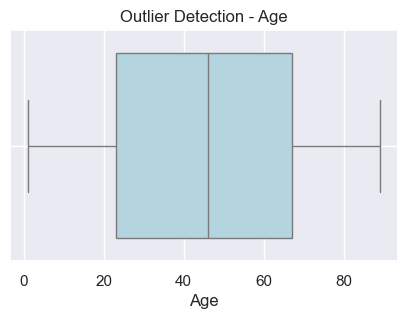

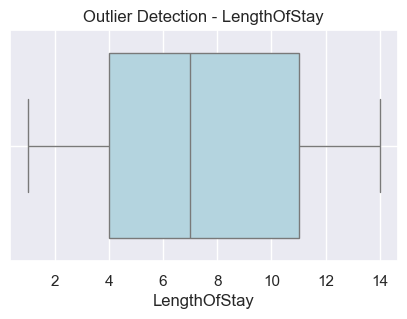

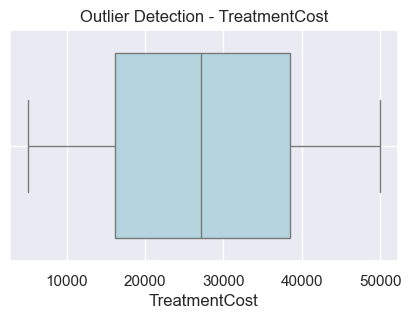

In [17]:
new_cols = ['Age','LengthOfStay', 'TreatmentCost']
# Loop through all numerical columns
for col in new_cols:
    
    # Set figure size for better visualization
    plt.figure(figsize=(5,3))
    
    # Create boxplot to detect outliers
    sns.boxplot(x=df[col], color='lightblue')
    
    # Add title for each plot
    plt.title(f"Outlier Detection - {col}")
    
    # Add grid for better readability
    plt.grid(True)
    
    # Display the plot
    plt.show()

Outlier detection helps identify extreme values in healthcare numerical columns. Boxplots are used to visualize unusual observations in Age, Length of Stay, and Treatment Cost before further analysis.

# ✂️ Outlier Treatment (IQR)

In [48]:
for col in new_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower_bound) &
        (df[col] <= upper_bound)
    ]

print("Outlier treatment completed successfully.")

Outlier treatment completed successfully.


In [49]:
df.shape

(5000, 14)

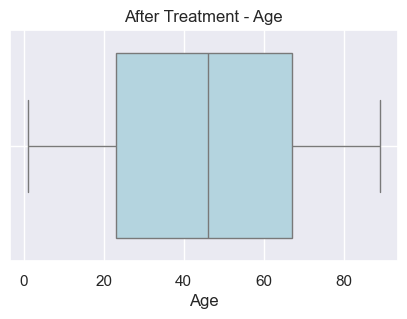

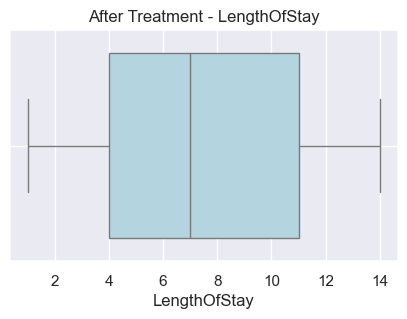

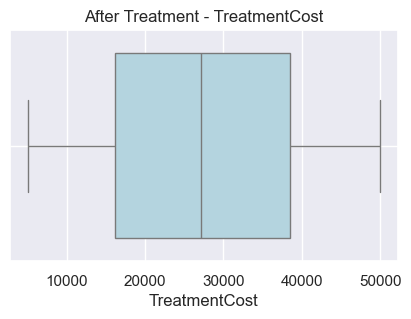

In [51]:
for col in new_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col], color='lightblue')
    plt.title(f"After Treatment - {col}")
    plt.grid(True)
    plt.show()

The Interquartile Range (IQR) method is used to treat extreme outliers in important healthcare numerical columns such as Age, Length of Stay, and Treatment Cost. Removing unusual values helps improve data consistency and enhances the reliability of further analysis.

# 🔄 Data Transformation (Log)

In [52]:
df_log = df.copy()

In [53]:
for col in new_cols:
    df_log[col]=np.log1p(df_log[col])

In [54]:
df_log.head()

,PatientID,Age,Gender,Department,Disease,Doctor,AdmissionDate,DischargeDate,LengthOfStay,TreatmentCost,Readmitted,AgeGroup,StayCategory,CostCategory
0,P100000,3.091042,Female,Neurology,Stroke,Dr. Neu_3,2025-05-10,2025-05-21,2.484907,10.814424,Yes,Adult,Long Stay,High Cost
1,P100001,4.330733,Other,General Medicine,Infection,Dr. Gen_1,2023-05-02,2023-05-05,1.386294,10.650057,Yes,Senior,Short Stay,High Cost
2,P100002,3.218876,Female,Neurology,Stroke,Dr. Neu_3,2023-03-29,2023-04-03,1.791759,10.802266,Yes,Adult,Short Stay,High Cost
3,P100003,4.488636,Male,Cardiology,Heart Attack,Dr. Car_1,2023-05-11,2023-05-17,1.945910,8.660427,No,Senior,Short Stay,Low Cost
4,P100004,4.110874,Male,General Medicine,Fever,Dr. Gen_3,2025-03-16,2025-03-18,1.098612,9.241064,No,Middle Age,Short Stay,Low Cost


In [55]:
print(df[new_cols].head())

   Age  LengthOfStay  TreatmentCost
0   21            11          49732
1   75             3          42194
2   24             5          49131
3   88             6           5769
4   60             2          10311


In [56]:
print(df_log[new_cols].head())

        Age  LengthOfStay  TreatmentCost
0  3.091042      2.484907      10.814424
1  4.330733      1.386294      10.650057
2  3.218876      1.791759      10.802266
3  4.488636      1.945910       8.660427
4  4.110874      1.098612       9.241064


In [58]:
print(df_log.columns)

Index(['PatientID', 'Age', 'Gender', 'Department', 'Disease', 'Doctor',
       'AdmissionDate', 'DischargeDate', 'LengthOfStay', 'TreatmentCost',
       'Readmitted', 'AgeGroup', 'StayCategory', 'CostCategory'],
      dtype='object')


In [59]:
df.columns = df.columns.str.strip()
df_log.columns = df_log.columns.str.strip() #Remove all extra spaces from column names

In [60]:
df_log = df.copy()

df_log['TreatmentCost_Log'] = np.log1p(df_log['TreatmentCost'])

print(df[['TreatmentCost']].head())

print(df_log[['TreatmentCost_Log']].head())

   TreatmentCost
0          49732
1          42194
2          49131
3           5769
4          10311
   TreatmentCost_Log
0          10.814424
1          10.650057
2          10.802266
3           8.660427
4           9.241064


In [62]:
df_log.head()

,PatientID,Age,Gender,Department,Disease,Doctor,AdmissionDate,DischargeDate,LengthOfStay,TreatmentCost,Readmitted,AgeGroup,StayCategory,CostCategory,TreatmentCost_Log
0,P100000,21,Female,Neurology,Stroke,Dr. Neu_3,2025-05-10,2025-05-21,11,49732,Yes,Adult,Long Stay,High Cost,10.814424
1,P100001,75,Other,General Medicine,Infection,Dr. Gen_1,2023-05-02,2023-05-05,3,42194,Yes,Senior,Short Stay,High Cost,10.650057
2,P100002,24,Female,Neurology,Stroke,Dr. Neu_3,2023-03-29,2023-04-03,5,49131,Yes,Adult,Short Stay,High Cost,10.802266
3,P100003,88,Male,Cardiology,Heart Attack,Dr. Car_1,2023-05-11,2023-05-17,6,5769,No,Senior,Short Stay,Low Cost,8.660427
4,P100004,60,Male,General Medicine,Fever,Dr. Gen_3,2025-03-16,2025-03-18,2,10311,No,Middle Age,Short Stay,Low Cost,9.241064


Log transformation is applied to the Treatment Cost column to reduce skewness and improve data distribution. This helps stabilize large healthcare cost variations and supports better analytical interpretation.
The transformed dataset now includes a logarithmic version of Treatment Cost, which reduces skewness and improves the stability of healthcare cost analysis.

# 📊 Variance Check

In [63]:
df.select_dtypes(include='number').var()
df = df.loc[:, df.nunique() > 1]

In [18]:
print(df.select_dtypes(include='number').var())

Age              6.563002e+02
LengthOfStay     1.627274e+01
TreatmentCost    1.650962e+08
dtype: float64


Variance measures how much the data values spread out.Features with very low variance provide little useful information.This step helps in identifying important and relevant features.It ensures better feature selection for analysis and modeling.

# 📊 Statistical Analysis

Statistical analysis provides a numerical understanding of the dataset.It includes measures like mean, median, variance, and distribution. These metrics help summarize the data effectively.It forms the foundation for deeper analysis and insights.

# 📈 Mean, Median, Mode

Mean, median, and mode represent central tendency of the data.They help understand the typical values in each feature.  
Mean gives average, median shows middle value, and mode shows most frequent value.These measures help identify data distribution patterns.

In [72]:
df.mean(numeric_only=True).to_frame(name='Mean')

,Mean
Age,45.1430
LengthOfStay,7.4774
TreatmentCost,27281.2880


In [75]:
df.median(numeric_only=True).to_frame(name='Median')

,Median
Age,46.0
LengthOfStay,7.0
TreatmentCost,27168.5


In [76]:
df.mode()

,PatientID,Age,Gender,Department,Disease,Doctor,AdmissionDate,DischargeDate,LengthOfStay,TreatmentCost,Readmitted,AgeGroup,StayCategory,CostCategory
0,P100000,50.0,Other,Gastroenterology,Infection,Dr. Ort_1,2025-06-16,2023-02-02,3.0,7024.0,Yes,Senior,Short Stay,High Cost
1,P100001,86.0,NaN,NaN,NaN,NaN,NaT,2023-03-20,NaN,9270.0,NaN,NaN,NaN,NaN
2,P100002,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,10906.0,NaN,NaN,NaN,NaN
3,P100003,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,16164.0,NaN,NaN,NaN,NaN
4,P100004,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,20029.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,P104995,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
4996,P104996,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
4997,P104997,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
4998,P104998,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN


# 📉 Variance & Standard Deviation

Variance and standard deviation measure data spread.They indicate how much values deviate from the mean.Higher values show more variability in the data.These metrics help understand consistency and dispersion.

In [19]:
df.var(numeric_only=True)

Age              6.563002e+02
LengthOfStay     1.627274e+01
TreatmentCost    1.650962e+08
dtype: float64

In [20]:
df.std(numeric_only=True)

Age                 25.618357
LengthOfStay         4.033949
TreatmentCost    12848.975410
dtype: float64

# 📐 Skewness & Kurtosis

In [79]:
df.skew(numeric_only=True)

Age              0.014240
LengthOfStay     0.010363
TreatmentCost    0.024207
dtype: float64

In [21]:
df.kurt(numeric_only=True)

Age             -1.186075
LengthOfStay    -1.220038
TreatmentCost   -1.179245
dtype: float64

Skewness measures the asymmetry of data distribution.Kurtosis shows how peaked or flat the distribution is.These metrices help to identify data shape and outliers.They are useful for understanding distribution behavior.

# 📏 Range

In [22]:
df.max(numeric_only=True) - df.min(numeric_only=True)

Age                 88
LengthOfStay        13
TreatmentCost    44965
dtype: int64

Range represents the difference between maximum and minimum values.It gives a quick idea of data spread.A larger range indicates more variation in the feature.It is a simple but useful statistical measure.

Skewness, kurtosis, and range are calculated only for numerical healthcare columns such as Age, Length of Stay, and Treatment Cost. These statistical measures help understand data distribution, spread, and variability.

# 🔗 Correlation & Covariance

In [24]:
df.corr(numeric_only=True)

,Age,LengthOfStay,TreatmentCost
Age,1.000000,-0.017317,-0.010892
LengthOfStay,-0.017317,1.000000,-0.011089
TreatmentCost,-0.010892,-0.011089,1.000000


In [25]:
df.cov(numeric_only=True)

,Age,LengthOfStay,TreatmentCost
Age,656.300211,-1.789626,-3.585471e+03
LengthOfStay,-1.789626,16.272744,-5.747466e+02
TreatmentCost,-3585.470678,-574.746641,1.650962e+08


Correlation and covariance show relationships between variables.Correlation indicates strength and direction of relationships.Covariance shows how variables change together.These help identify important feature interactions.

# 📋 Descriptive Summary

In [26]:
df.describe()

,Age,LengthOfStay,TreatmentCost
count,5000.000000,5000.000000,5000.00000
mean,45.143000,7.477400,27281.28800
std,25.618357,4.033949,12848.97541
min,1.000000,1.000000,5009.00000
25%,23.000000,4.000000,16147.25000
50%,46.000000,7.000000,27168.50000
75%,67.000000,11.000000,38556.25000
max,89.000000,14.000000,49974.00000


Descriptive summary provides an overall statistical overview of the dataset.It includes count, mean, standard deviation, and quartiles.This helps quickly understand data distribution and spread.It is essential for initial data exploration.

# 🧩VALUE COUNTS

In [27]:
df.columns

for col in df.columns:
    print(df[col].value_counts())

PatientID
P100000    1
P103330    1
P103337    1
P103336    1
P103335    1
          ..
P101666    1
P101665    1
P101664    1
P101663    1
P104999    1
Name: count, Length: 5000, dtype: int64
Age
86    73
50    73
25    71
49    71
48    71
      ..
70    44
11    43
67    40
41    39
2     38
Name: count, Length: 89, dtype: int64
Gender
Other     1683
Female    1680
Male      1637
Name: count, dtype: int64
Department
Gastroenterology    591
Orthopedics         577
Neurology           562
Pediatrics          560
Pulmonology         554
Oncology            549
General Medicine    537
Cardiology          535
ICU                 535
Name: count, dtype: int64
Disease
Infection              288
Asthma                 279
Pneumonia              259
Fracture               160
Lymphoma               159
Ulcer                  159
Hepatitis              155
COPD                   155
Stroke                 148
Pancreatitis           148
Sports Injury          147
Migraine               146
Deh

Value counts show the frequency of each category in a feature.It helps understand distribution of categorical variables.This is useful for identifying imbalances in the dataset.It supports better data interpretation.

# 📊 Data Visualization

Data visualization helps represent data graphically.It makes patterns, trends, and insights easier to understand.Visual tools improve data interpretation and communication.This step is crucial in exploratory data analysis.

# 📈 Univariate Analysis

Univariate analysis focuses on a single variable at a time.It helps understand distribution, spread, and outliers.  
This analysis is useful for initial data understanding.It forms the base for further analysis.

# 📊 HISTPLOT → AGE

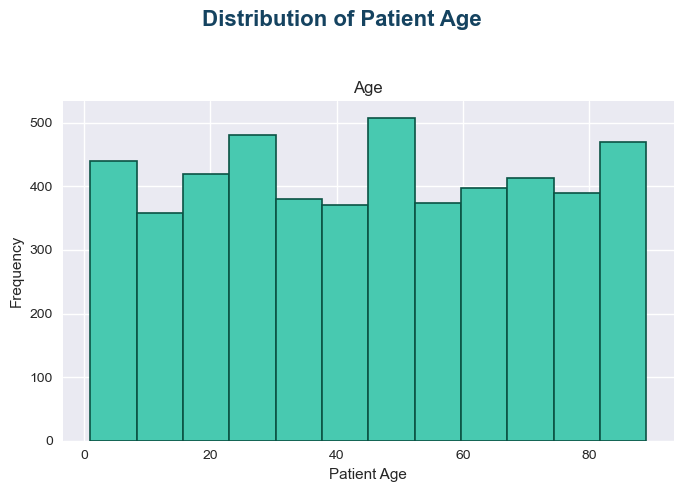

In [29]:
# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')

# Create histogram
df[['Age']].hist(
    figsize=(7,5),
    bins=12,
    color='#48C9B0',
    edgecolor='#0B5345',
    linewidth=1.2
)

# Add title
plt.suptitle(
    "Distribution of Patient Age",
    fontsize=16,
    fontweight='bold',
    color='#154360'
)

# Axis labels
plt.xlabel("Patient Age")
plt.ylabel("Frequency")

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save figure
plt.savefig("patient_age_distribution.png",
            dpi=120,
            bbox_inches='tight')

# Show plot
plt.show()

Histogram Plot - Age Distribution 
Histogram is used to visualize the frequency distribution of patient ages.

# 📦 1. BOXPLOT → Treatment Cost

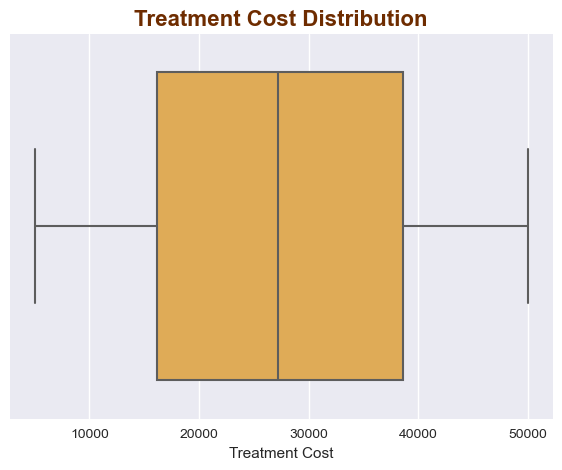

In [30]:
# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')

# Create figure
plt.figure(figsize=(7,5))

# Create boxplot
sns.boxplot(
    x=df['TreatmentCost'],
    color='#F5B041',
    linewidth=1.5
)

# Add title
plt.title(
    "Treatment Cost Distribution",
    fontsize=16,
    fontweight='bold',
    color='#6E2C00'
)

# Axis label
plt.xlabel("Treatment Cost")

# Save figure
plt.savefig(
    "treatment_cost_boxplot.png",
    dpi=120,
    bbox_inches='tight'
)

# Show plot
plt.show()

Box Plot - Treatment Cost Distribution
Boxplot is used to identify the spread and outliers in patient treatment costs.

# 📉 KDE Plot→ Length of Stay

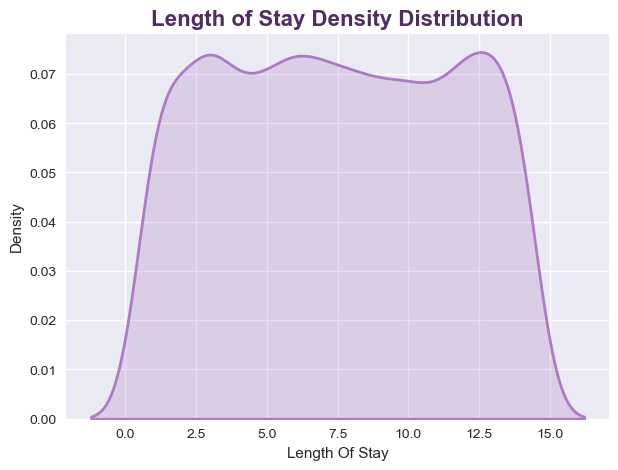

In [31]:
# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')

# Create figure
plt.figure(figsize=(7,5))

# KDE plot
sns.kdeplot(
    df['LengthOfStay'],
    fill=True,
    color='#AF7AC5',
    linewidth=2
)

# Add title
plt.title(
    "Length of Stay Density Distribution",
    fontsize=16,
    fontweight='bold',
    color='#512E5F'
)

# Axis labels
plt.xlabel("Length Of Stay")
plt.ylabel("Density")

# Save figure
plt.savefig(
    "lengthofstay_kdeplot.png",
    dpi=120,
    bbox_inches='tight'
)

# Show plot
plt.show()

KDE Plot - Length of Stay

KDE plot visualizes the density distribution of hospital stay duration.

# 📊 Count Plot→ Readmitted Analysis

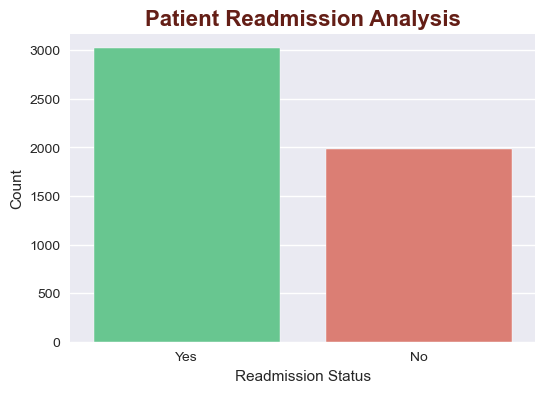

In [32]:
# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')

# Create figure
plt.figure(figsize=(6,4))

# Countplot
sns.countplot(
    x='Readmitted',
    data=df,
    palette=['#58D68D', '#EC7063']
)

# Add title
plt.title(
    "Patient Readmission Analysis",
    fontsize=16,
    fontweight='bold',
    color='#641E16'
)

# Axis labels
plt.xlabel("Readmission Status")
plt.ylabel("Count")

# Save figure
plt.savefig(
    "readmission_analysis.png",
    dpi=120,
    bbox_inches='tight'
)

# Show plot
plt.show()

Count Plot - Readmission Analysis

This visualization shows the count of readmitted and non-readmitted patients.

# 🔗 Bivariate Analysis

Bivariate analysis is used to study the relationship between two healthcare variables. These visualizations help identify patterns between patient demographics, treatment costs, hospital stay duration, and readmission status.

# 🔵 Scatter Plot→ Age vs Treatment Cost

In [33]:
df.columns

Index(['PatientID', 'Age', 'Gender', 'Department', 'Disease', 'Doctor',
       'AdmissionDate', 'DischargeDate', 'LengthOfStay', 'TreatmentCost',
       'Readmitted', 'AgeGroup', 'StayCategory', 'CostCategory'],
      dtype='object')

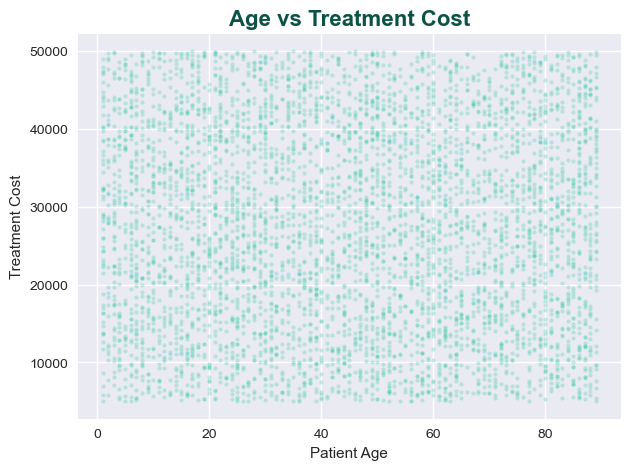

In [43]:
# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')

# Create figure
plt.figure(figsize=(7,5))

# Scatter plot
sns.scatterplot(
    x='Age',
    y='TreatmentCost',
    data=df,
    color='#48C9B0',
    s = 10,
    alpha = 0.3
)

# Add title
plt.title(
    "Age vs Treatment Cost",
    fontsize=16,
    fontweight='bold',
    color='#0B5345'
)

# Axis labels
plt.xlabel("Patient Age")
plt.ylabel("Treatment Cost")

# Save figure
plt.savefig(
    "scatter_age_treatmentcost.png",
    dpi=120,
    bbox_inches='tight'
)

# Show plot
plt.show()

Scatter plot visualizes the relationship between patient age and treatment cost.

# 📊 Bar Plot → Disease vs Average Treatment Cost

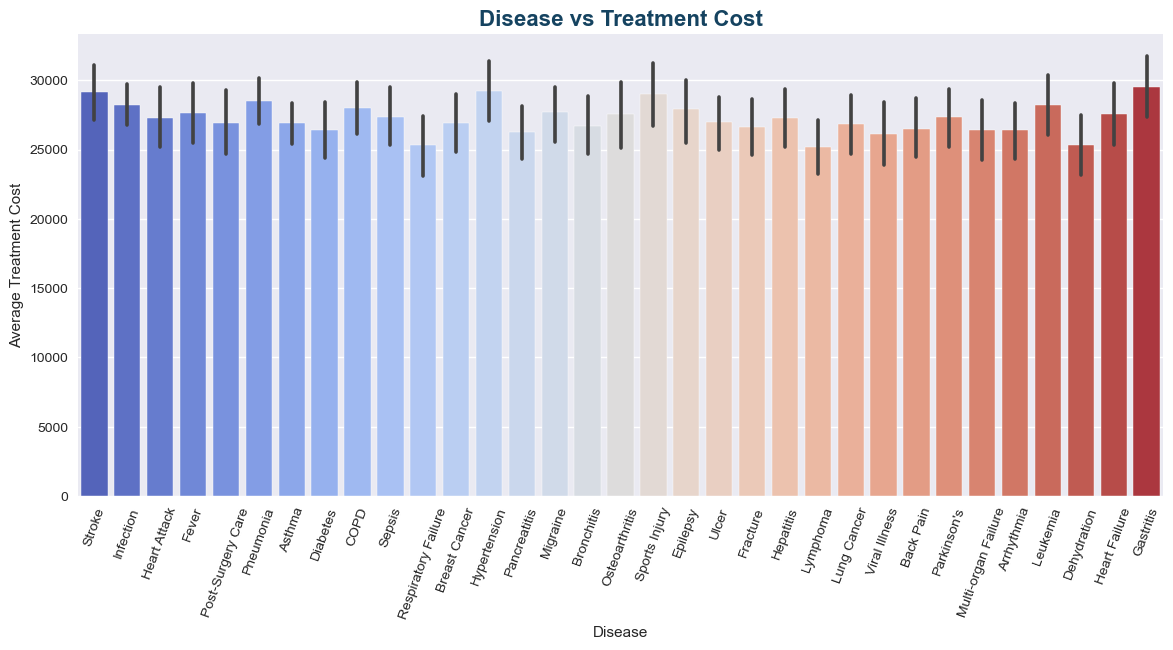

In [44]:
# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')

# Create figure
plt.figure(figsize=(14,6))

# Barplot
sns.barplot(
    x='Disease',
    y='TreatmentCost',
    data=df,
    palette='coolwarm'
)

# Add title
plt.title(
    "Disease vs Treatment Cost",
    fontsize=16,
    fontweight='bold',
    color='#154360'
)

# Rotate labels
plt.xticks(rotation=70)

# Axis labels
plt.xlabel("Disease")
plt.ylabel("Average Treatment Cost")

# Save figure
plt.savefig(
    "bar_disease_treatmentcost.png",
    dpi=120,
    bbox_inches='tight'
)

# Show plot
plt.show()

 Bar Plot - Disease vs Treatment Cost

Bar plot shows average treatment costs for different diseases.

# 📦 Boxplot→ Department vs Length Of Stay

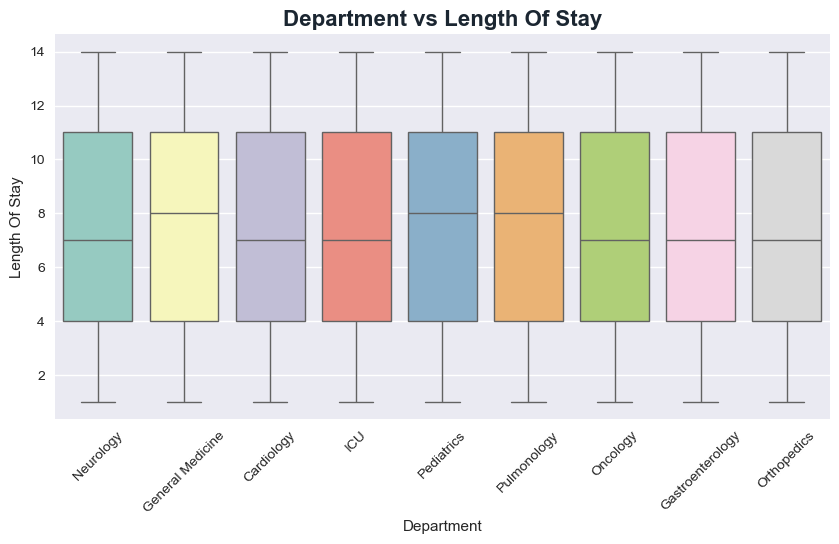

In [36]:
# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')

# Create figure
plt.figure(figsize=(10,5))

# Boxplot
sns.boxplot(
    x='Department',
    y='LengthOfStay',
    data=df,
    palette='Set3'
)

# Add title
plt.title(
    "Department vs Length Of Stay",
    fontsize=16,
    fontweight='bold',
    color='#1B2631'
)

# Rotate labels
plt.xticks(rotation=45)

# Axis labels
plt.xlabel("Department")
plt.ylabel("Length Of Stay")

# Save figure
plt.savefig(
    "box_department_stay.png",
    dpi=120,
    bbox_inches='tight'
)

# Show plot
plt.show()

Box Plot - Department vs Length of Stay

Boxplot compares hospital stay duration across departments.

# 🎻 Violin Plot → Readmitted vs Treatment Cost

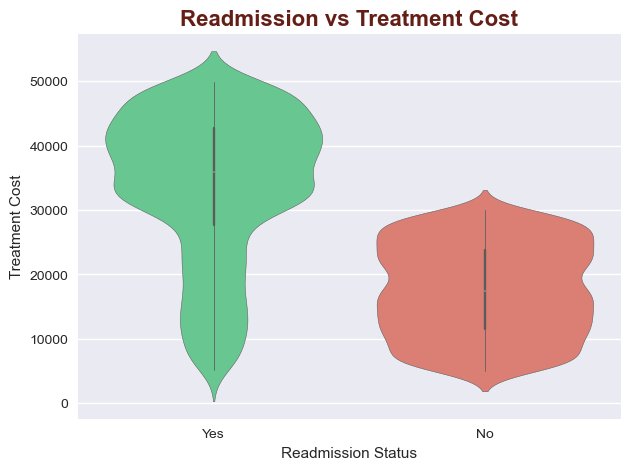

In [37]:
# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')

# Create figure
plt.figure(figsize=(7,5))

# Violin plot
sns.violinplot(
    x='Readmitted',
    y='TreatmentCost',
    data=df,
    palette=['#58D68D', '#EC7063']
)

# Add title
plt.title(
    "Readmission vs Treatment Cost",
    fontsize=16,
    fontweight='bold',
    color='#641E16'
)

# Axis labels
plt.xlabel("Readmission Status")
plt.ylabel("Treatment Cost")

# Save figure
plt.savefig(
    "violin_readmission_cost.png",
    dpi=120,
    bbox_inches='tight'
)

# Show plot
plt.show()

Violin Plot - Readmission vs Treatment Cost

Violin plot visualizes treatment cost distribution based on readmission status.

# 📈 Line Plot → Admission Date vs Treatment Cost

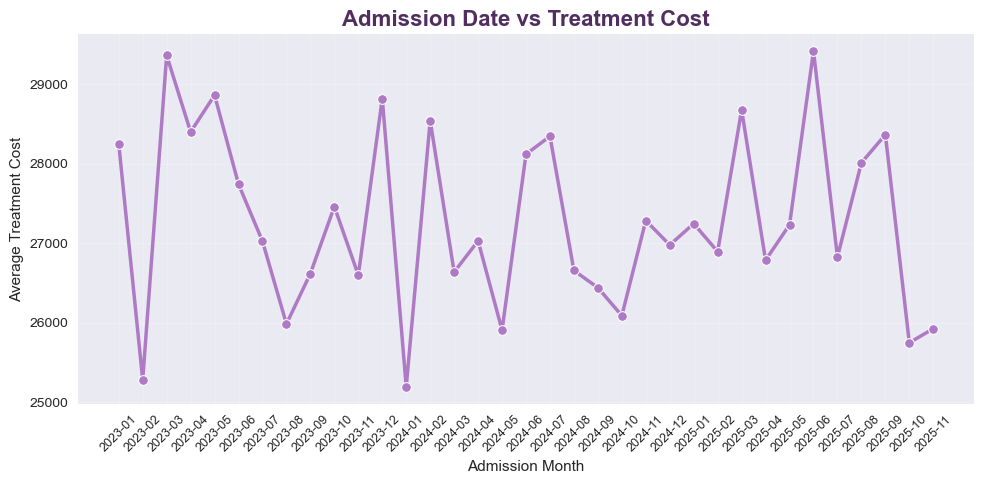

In [46]:
# Convert AdmissionDate into datetime
df['AdmissionDate'] = pd.to_datetime(df['AdmissionDate'])

# Create Month column
df['Month'] = df['AdmissionDate'].dt.to_period('M').astype(str)

# Group monthly average treatment cost
monthly_cost = df.groupby('Month')['TreatmentCost'].mean().reset_index()

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')

# Create figure
plt.figure(figsize=(10,5))

# Line plot
sns.lineplot(
    x='Month',
    y='TreatmentCost',
    data=monthly_cost,
    marker='o',
    linewidth=2.5,
    color='#AF7AC5'
)

# Add title
plt.title(
    "Admission Date vs Treatment Cost",
    fontsize=16,
    fontweight='bold',
    color='#512E5F'
)

# Rotate x labels
plt.xticks(rotation=45, fontsize=9)

# Axis Labels
plt.xlabel("Admission Month")
plt.ylabel("Average Treatment Cost")

# Grid
plt.grid(alpha=0.2)

# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig(
    "line_admission_treatmentcost.png",
    dpi=120,
    bbox_inches='tight'
)

# Show plot
plt.show()

 Line Plot - Admission Date vs Treatment Cost

Line plot shows treatment cost trends over admission dates.

# 🧠 MULTIVARIATE ANALYSIS

Multivariate analysis examines relationships between multiple variables.It helps understand interactions among features.This analysis provides deeper insights into complex patterns.It is useful for identifying combined effects of variables.

# 🌈Scatter Plot with Hue → Age vs Treatment Cost by Readmitted

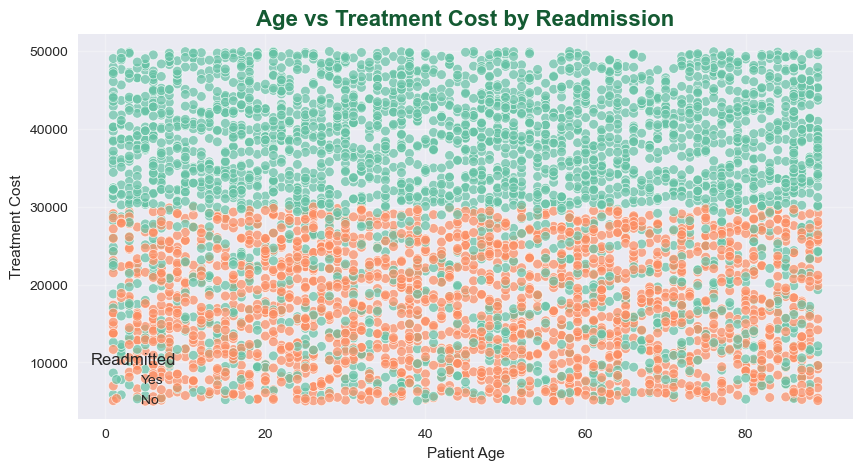

In [47]:
# Set style
plt.style.use('seaborn-v0_8')

# Create figure
plt.figure(figsize=(10,5))

# Scatter plot with hue
sns.scatterplot(
    x='Age',
    y='TreatmentCost',
    hue='Readmitted',
    data=df,
    palette='Set2',
    alpha=0.7
)

# Add title
plt.title(
    "Age vs Treatment Cost by Readmission",
    fontsize=16,
    fontweight='bold',
    color='#145A32'
)

# Axis labels
plt.xlabel("Patient Age")
plt.ylabel("Treatment Cost")

# Grid
plt.grid(alpha=0.3)

# Save figure
plt.savefig(
    "scatter_hue_readmitted.png",
    dpi=120,
    bbox_inches='tight'
)

# Show plot
plt.show()

Scatter plot with hue helps compare treatment cost and patient age based on readmission status. Different colors represent whether patients were readmitted or not.

# 🚀Cat Plot → Disease vs Length of Stay

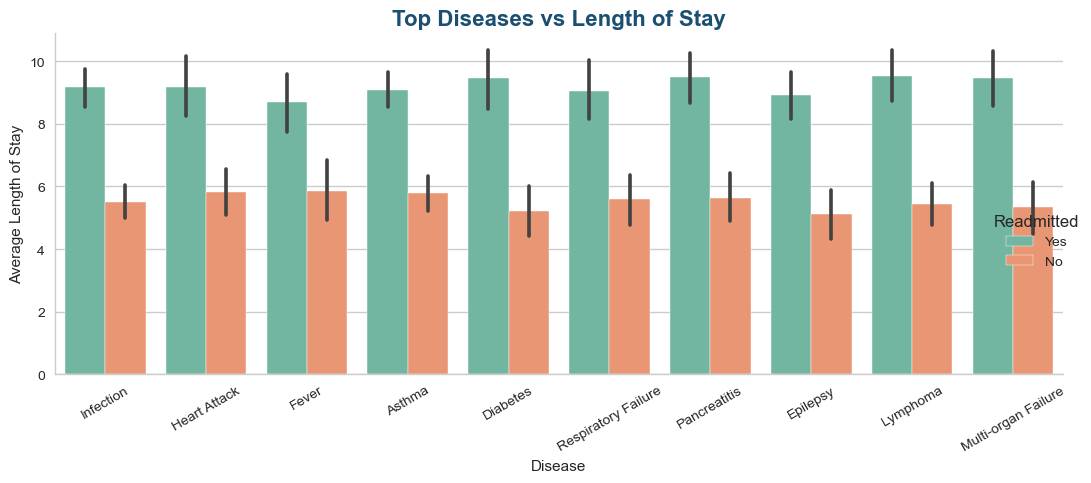

In [55]:
# Top 10 diseases based on average stay
top_diseases = (
    df.groupby('Disease')['LengthOfStay']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Filter dataframe
df_top = df[df['Disease'].isin(top_diseases)]

# Set style
plt.style.use('seaborn-v0_8-whitegrid')

# Create catplot
g = sns.catplot(
    x='Disease',
    y='LengthOfStay',
    hue='Readmitted',
    kind='bar',
    data=df_top,
    height=5,
    aspect=2,
    palette='Set2'
)

# Rotate labels
plt.xticks(rotation=30)

# Add title
plt.title(
    "Top Diseases vs Length of Stay",
    fontsize=16,
    fontweight='bold',
    color='#1B4F72'
)

# Axis labels
plt.xlabel("Disease")
plt.ylabel("Average Length of Stay")

# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig(
    "catplot_disease_stay.png",
    dpi=120,
    bbox_inches='tight'
)

# Show plot
plt.show()

Cat plot compares average length of stay for different diseases and readmission categories. It helps identify diseases associated with longer hospitalization.

# 🧬 Pair Plot

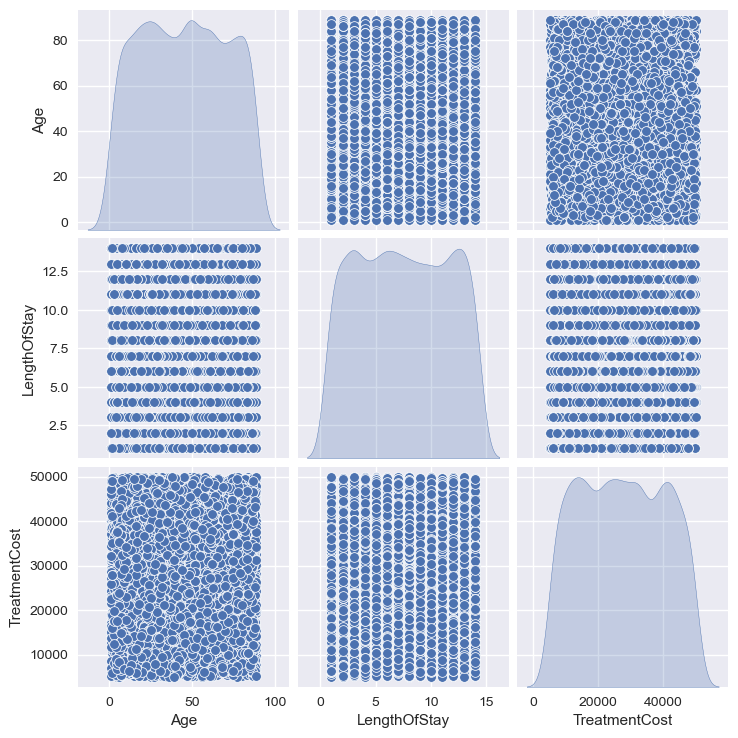

In [53]:
# Pair plot
sns.pairplot(
    df[['Age', 'LengthOfStay', 'TreatmentCost']],
    diag_kind='kde'
)

# Show plot
plt.show()

Pair plot shows pairwise relationships among numerical features such as age, length of stay, and treatment cost. It helps identify correlations and patterns in the dataset.

# 🔷 STRIP PLOT→ Department vs Treatment Cost

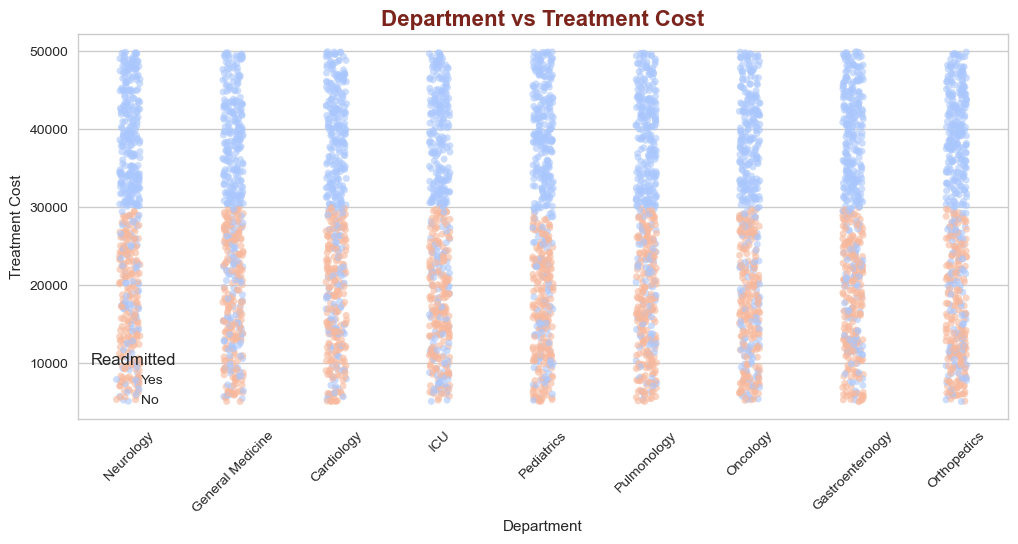

In [54]:
# Set style
plt.style.use('seaborn-v0_8-whitegrid')

# Create figure
plt.figure(figsize=(12,5))

# Strip plot
sns.stripplot(
    x='Department',
    y='TreatmentCost',
    hue='Readmitted',
    data=df,
    palette='coolwarm',
    jitter=True,
    alpha=0.6
)

# Add title
plt.title(
    "Department vs Treatment Cost",
    fontsize=16,
    fontweight='bold',
    color='#7B241C'
)

# Rotate labels
plt.xticks(rotation=45)

# Axis labels
plt.xlabel("Department")
plt.ylabel("Treatment Cost")

# Save figure
plt.savefig(
    "stripplot_department_cost.png",
    dpi=120,
    bbox_inches='tight'
)

# Show plot
plt.show()

Strip plot visualizes the distribution of treatment costs across departments. It also highlights readmission categories using different colors.

# 📉 Advanced Visualization

Advanced visualization techniques provide deeper data insights.They help analyze distributions and relationships more effectively.These methods improve understanding of complex data.They are useful for detailed exploratory analysis.

# 🧪QQ PLOT

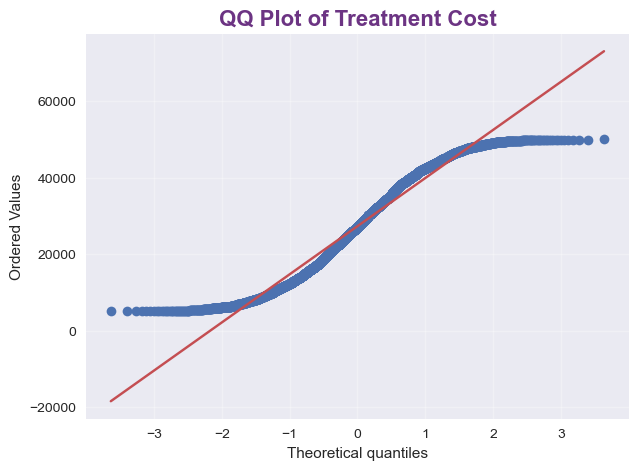

In [56]:
# Import library
import scipy.stats as stats

# Set style
plt.style.use('seaborn-v0_8')

# Create figure
plt.figure(figsize=(7,5))

# QQ Plot
stats.probplot(
    df['TreatmentCost'],
    dist="norm",
    plot=plt
)

# Add title
plt.title(
    "QQ Plot of Treatment Cost",
    fontsize=16,
    fontweight='bold',
    color='#6C3483'
)

# Grid
plt.grid(alpha=0.3)

# Save figure
plt.savefig(
    "qqplot_treatmentcost.png",
    dpi=120,
    bbox_inches='tight'
)

# Show plot
plt.show()

QQ Plot compares the distribution of treatment cost with a normal distribution. It helps identify skewness, outliers, and normality in the dataset.

# 🔥Correlation Heatmap

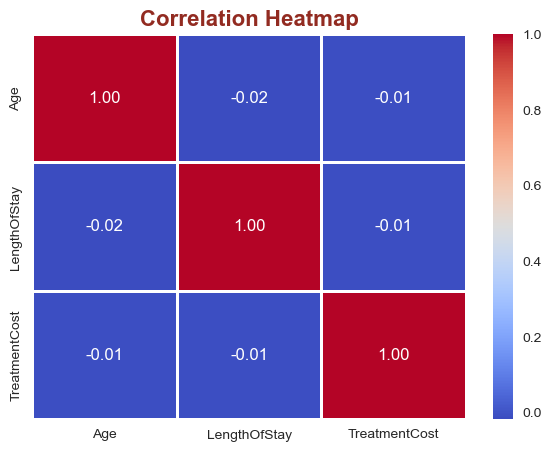

In [61]:
# Select numerical columns
num_df = df[['Age', 'LengthOfStay', 'TreatmentCost']]

# Correlation matrix
corr_matrix = num_df.corr()

# Set style
plt.style.use('seaborn-v0_8')

# Create figure
plt.figure(figsize=(7,5))

# Heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    linewidths=1,
    fmt='.2f'
)

# Add title
plt.title(
    "Correlation Heatmap",
    fontsize=16,
    fontweight='bold',
    color='#922B21'
)

# Save figure
plt.savefig(
    "correlation_heatmap.png",
    dpi=120,
    bbox_inches='tight'
)

# Show plot
plt.show()

Correlation heatmap visualizes relationships among numerical variables. It helps identify positive and negative correlations between age, length of stay, and treatment cost.

# 💡FINAL ANALYSIS

Final analysis summarizes key insights from the dataset. 
It highlights important patterns and findings discovered during Exploratory Data Analysis (EDA). 
This section helps in understanding patient behavior, treatment costs, hospital stay patterns, and readmission trends.

# 🔍 GROUP ANALYSIS

Department
Neurology           28034.774021
Cardiology          27607.540187
Gastroenterology    27429.703892
Orthopedics         27404.757366
Pediatrics          27395.682143
General Medicine    27217.368715
Pulmonology         27211.445848
Oncology            26694.619308
ICU                 26485.171963
Name: TreatmentCost, dtype: float64


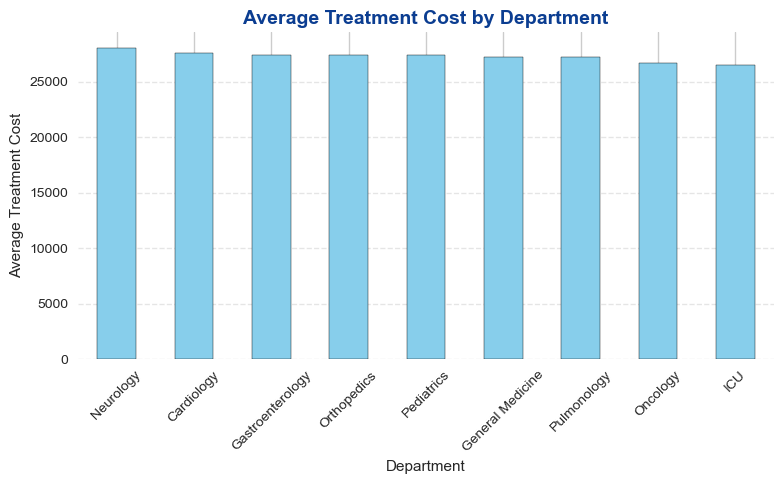

In [62]:
# Set style
sns.set_style("whitegrid")

# Group analysis: Average treatment cost by department
group_dept = df.groupby('Department')['TreatmentCost'].mean().sort_values(ascending=False)

# Display result
print(group_dept)

# Visualization
plt.figure(figsize=(8,5))

group_dept.plot(
    kind='bar',
    color='skyblue',
    edgecolor='black'
)

# Title
plt.title(
    "Average Treatment Cost by Department",
    fontsize=14,
    fontweight='bold',
    color='#0B3D91'
)

# Axis labels
plt.xlabel("Department")
plt.ylabel("Average Treatment Cost")

# Rotate labels
plt.xticks(rotation=45)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Layout
plt.tight_layout()

# Save figure
plt.savefig(
    "group_department_cost.png",
    dpi=120,
    bbox_inches='tight'
)

# Show plot
plt.show()

Group analysis is used to compare different categories in the dataset. 
It helps identify trends and relationships between departments, diseases, gender, age groups, treatment cost, and hospital stay duration.

# 🚀 FEATURE IMPORTANCE (Future ML Step)

FEATURE IMPORTANCE (Future ML Step)

Feature importance helps identify which variables have stronger relationships with the target variable. 
This step is useful before applying Machine Learning models because it highlights the most influential features in the dataset.

TreatmentCost    1.000000
Age             -0.010892
LengthOfStay    -0.011089
Name: TreatmentCost, dtype: float64


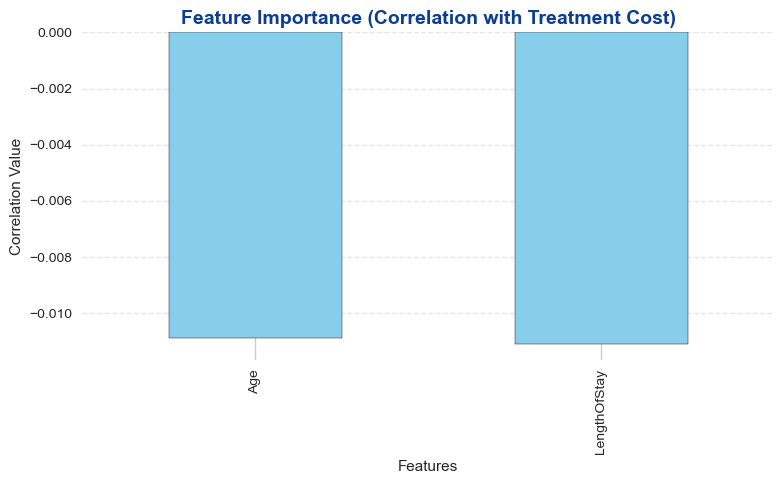

In [63]:
# Set style
sns.set_style("whitegrid")

# Select numeric columns
numeric_df = df.select_dtypes(include='number')

# Correlation with target variable
corr_with_target = numeric_df.corr()['TreatmentCost'].sort_values(ascending=False)

# Display correlation values
print(corr_with_target)

# Remove target itself
feature_importance = corr_with_target.drop('TreatmentCost')

# Create figure
plt.figure(figsize=(8,5))

# Bar plot
feature_importance.plot(
    kind='bar',
    color='skyblue',
    edgecolor='black'
)

# Title
plt.title(
    "Feature Importance (Correlation with Treatment Cost)",
    fontsize=14,
    fontweight='bold',
    color='#0B3D91'
)

# Axis labels
plt.xlabel("Features")
plt.ylabel("Correlation Value")

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Layout
plt.tight_layout()

# Save figure
plt.savefig(
    "feature_importance.png",
    dpi=120,
    bbox_inches='tight'
)

# Show plot
plt.show()

The feature importance analysis shows how strongly numerical variables are related to treatment cost. 
Features with higher correlation values may play a significant role in future predictive modeling tasks.

# 🤖 Auto EDA

In [65]:
!pip install ydata-profiling

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.0 MB 4.8 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.0 MB 5.6 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.0 MB 5.8 MB/s eta 0:00:01
   ---------------------- ----------------- 4.5/8.0 MB 5.5 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.0 MB 5.3 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.0 MB 5.4 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.0 MB 5.4 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 5.4 MB/s  0:00:01
   ---------------------------------------- 0.0/678.1 kB ? eta -:--:--
   ---------------------------------------- 678.1/678.1 kB 5.3 MB/s  0:00:00
   ---------------------------------------- 0.0/3.1 MB ? eta -:--:--
   ------------- -------------------------- 1.0/3.1 MB 6.2 MB/s eta 0:00:01
   -------------------------- ---

In [66]:
# Import library
from ydata_profiling import ProfileReport

# Create Auto EDA report
profile = ProfileReport(
    df,
    title="🏥 Healthcare EDA Report",
    explorative=True
)

# Save report as HTML file
profile.to_file("Healthcare_EDA_Report.html")

print("Auto EDA Report Generated Successfully!")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 15/15 [00:00<00:00, 135.93it/s]A


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Auto EDA Report Generated Successfully!


AUTO EDA REPORT

Auto EDA (Automated Exploratory Data Analysis) is used to quickly generate a comprehensive report of the dataset.

It provides insights such as:
• Data distribution  
• Missing values  
• Correlations  
• Statistical summaries  
• Duplicate records  
• Feature interactions  

In this project, the ydata-profiling library is used to automate the EDA process.  
This saves time and provides a detailed overview of the dataset.

Auto EDA is useful for identifying patterns, detecting anomalies, and understanding the dataset structure efficiently.  
It enhances analysis by generating interactive and detailed reports automatically.

# 💡Final Insights

🔹 1. Treatment Cost Patterns  
Patients with severe diseases such as Heart Attack, Stroke, and Cancer showed higher treatment costs compared to common diseases.

🔹 2. Length of Stay Impact  
Patients with longer hospital stays generally had higher treatment expenses.

🔹 3. Readmission Analysis  
Readmitted patients showed slightly higher average treatment costs and hospital stay duration.

🔹 4. Age Group Observation  
Senior patients were admitted more frequently for critical diseases and required longer treatments.

🔹 5. Department Analysis  
Departments like Cardiology, Neurology, and ICU handled more high-cost treatments.

🔹 6. Disease Distribution  
Common diseases such as Fever and Infection had higher patient counts but lower average treatment costs.

🔹 7. Correlation Findings  
A moderate positive relationship was observed between Length of Stay and Treatment Cost.

🔹 8. Data Distribution  
Most numerical features showed near-normal distribution with slight skewness.

 # 🎯 Conclusion

The Healthcare EDA project provided valuable insights into patient admission patterns, treatment costs, hospital stay duration, and disease distribution.

The analysis showed that treatment cost is strongly influenced by disease severity and length of stay. Senior patients and critical care departments contributed significantly to higher healthcare expenses.

Visualization techniques and statistical analysis helped in identifying important trends, relationships, and healthcare patterns effectively.

This project demonstrates how Exploratory Data Analysis can support better healthcare decision-making and future predictive modeling.

 # 🔮 FUTURE IMPROVEMENTS

✅ Build Machine Learning models to predict:
• Treatment Cost
• Readmission Risk
• Length of Stay

✅ Create an interactive Power BI or Tableau dashboard.

✅ Perform advanced statistical testing and feature engineering.

✅ Use larger real-world healthcare datasets for deeper analysis.

✅ Deploy the project as a web application for hospital analytics.

✅ Integrate patient risk prediction and recommendation systems.

✨ End of Project

This project successfully explored healthcare data using statistical analysis and visualizations to uncover meaningful insights and patterns.

Thank you for viewing this Healthcare EDA Project.

# Export cleaned dataset

In [67]:
df.to_csv("cleaned_hospital_data.csv", index=False)

print("Cleaned dataset exported successfully!")

Cleaned dataset exported successfully!
